# Giai đoạn 1 — Làm sạch phiếu khảo sát

```
┌────────────────────────────────────────────────────────────────────────────┐
│                             01_LamSachKhaoSat                              │
└────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • data/raw/khao_sat_dinh_huong_nganh_hoc_clean.csv
         │
         ▼
  XỬ LÝ
    1. Loại phiếu điền đại: 10 câu Likert cùng một mức (độ lệch = 0)
    2. Loại phiếu thiếu ngành học, hoặc không có môn điểm nào
    3. Gắn mã ngành và khối ngành theo bảng chuẩn
    4. Thống kê phân bố ngành · khối · Likert · điểm · nhân khẩu học
         │
         ▼
  ĐẦU RA
    • 01_LamSachKhaoSat/khaosat_sach.csv  —  phiếu dùng được
    • 01_LamSachKhaoSat/mapping.json      —  NGUỒN CHUẨN cho 9 giai đoạn sau
    • 01_LamSachKhaoSat/hinh_1_*.png      —  5 hình
```

## Vì sao phải loại phiếu "điền đại"

Khảo sát online luôn có người bấm cho xong. Dấu hiệu rõ nhất: **10 câu Likert chọn cùng một mức** —
tất cả đều 3, hoặc tất cả đều 5. Về mặt số, phiếu đó có độ lệch chuẩn bằng 0.

Những phiếu này **độc hại hơn là vô dụng**: chúng nói *"em thích mọi thứ như nhau"*, trong khi mô
hình đi tìm chính sự khác biệt giữa các sở thích. Giữ lại thì mô hình học rằng nhiều học sinh không
có thiên hướng gì — sai với thực tế và làm nhiễu mọi ranh giới giữa các ngành.

## `mapping.json` là nguồn chuẩn duy nhất

Bảng ánh xạ sinh ra ở đây được **mọi giai đoạn sau đọc lại**, không notebook nào được tự định nghĩa
lại danh sách ngành. Pipeline trước để mỗi nơi một bản rồi trôi lệch nhau, dẫn tới báo cáo ghi một
đằng code chạy một nẻo.

Đây cũng là **file duy nhất khác nhau** giữa `research2` (7 khối HUIT) và `research3` — nhờ vậy hai
nhánh là một thí nghiệm có đối chứng đúng nghĩa.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

TEN_KHOI = {
    0: "CNTT & Máy tính",
    1: "Kinh doanh & Quản lý",
    2: "Du lịch, Khách sạn & Ẩm thực",
    3: "Kỹ thuật & Công nghệ",
    4: "Thực phẩm, Sinh học & Môi trường",
    5: "Luật",
    6: "Ngoại ngữ",
}

KHOI = {
    1: [   # Kinh doanh & Quản lý — 10 ngành
        ("Công nghệ tài chính", 7340205),
        ("Kinh doanh quốc tế", 7340120),
        ("Kinh doanh thời trang và dệt may", 7340123),
        ("Kế toán", 7340301),
        ("Logistics và quản lý chuỗi cung ứng", 7510605),
        ("Marketing", 7340115),
        ("Quản lý Công nghiệp", 7510601),
        ("Quản trị kinh doanh", 7340101),
        ("Thương mại điện tử", 7340122),
        ("Tài chính ngân hàng", 7340201),
    ],
    3: [   # Kỹ thuật & Công nghệ — 8 ngành
        ("Công nghệ chế tạo máy", 7510202),
        ("Công nghệ dệt, may", 7540204),
        ("Công nghệ kỹ thuật cơ điện tử", 7510203),
        ("Công nghệ kỹ thuật hóa học", 7510401),
        ("Công nghệ kỹ thuật điều khiển và TĐH", 7510303),
        ("Công nghệ kỹ thuật điện - điện tử", 7510301),
        ("Công nghệ vật liệu", 7510402),
        ("Kỹ thuật nhiệt", 7520115),
    ],
    4: [   # Thực phẩm, Sinh học & Môi trường — 7 ngành
        ("Công nghệ chế biến thủy sản", 7540105),
        ("Công nghệ kỹ thuật môi trường", 7510406),
        ("Công nghệ sinh học", 7420201),
        ("Công nghệ thực phẩm", 7540101),
        ("Quản lý tài nguyên và môi trường", 7850101),
        ("Quản trị kinh doanh thực phẩm", 7340129),
        ("Đảm bảo chất lượng và an toàn thực phẩm", 7540106),
    ],
    2: [   # Du lịch, Khách sạn & Ẩm thực — 6 ngành
        ("Du lịch", 7810101),
        ("Khoa học chế biến món ăn", 7819010),
        ("Khoa học dinh dưỡng và ẩm thực", 7819009),
        ("Quản trị dịch vụ du lịch và lữ hành", 7810103),
        ("Quản trị khách sạn", 7810201),
        ("Quản trị nhà hàng và dịch vụ ăn uống", 7810202),
    ],
    0: [   # CNTT & Máy tính — 4 ngành
        ("An toàn thông tin", 7480202),
        ("Công nghệ thông tin", 7480201),
        ("Khoa học dữ liệu", 7460108),
        ("Trí tuệ nhân tạo", 7480107),
    ],
    5: [   # Luật — 2 ngành
        ("Luật", 7380101),
        ("Luật kinh tế", 7380107),
    ],
    6: [   # Ngoại ngữ — 2 ngành
        ("Ngôn ngữ Anh", 7220201),
        ("Ngôn ngữ Trung Quốc", 7220204),
    ],
}

OUT = thu_muc(1)
tho = pd.read_csv(RAW / "khao_sat_dinh_huong_nganh_hoc_clean.csv")

TEN_TO_MA = {t: m for ds in KHOI.values() for t, m in ds}
MA_TO_TEN = {m: t for t, m in TEN_TO_MA.items()}
NGANH_TO_KHOI = {m: k for k, ds in KHOI.items() for _, m in ds}
L = [c for c in tho.columns if c.startswith("likert_")]
C_DIEM = [c for c in tho.columns if c.startswith("diem_")]

assert len(TEN_TO_MA) == 39, f"phải đủ 39 ngành, đang có {len(TEN_TO_MA)}"
print(f"Đọc      : {len(tho)} phiếu · {len(tho.columns)} cột")
print(f"Taxonomy : {len(TEN_TO_MA)} ngành → {len(KHOI)} khối")
print(f"Cỡ khối  : {sorted((len(v) for v in KHOI.values()), reverse=True)}")
print(f"Likert   : {len(L)} câu · Điểm: {len(C_DIEM)} môn")

Đọc      : 766 phiếu · 27 cột
Taxonomy : 39 ngành → 7 khối
Cỡ khối  : [10, 8, 7, 6, 4, 2, 2]
Likert   : 10 câu · Điểm: 10 môn


## 1. Phễu lọc

In [2]:
buoc = [("Phiếu thu được", len(tho))]
d = tho.copy()

# ── Bước 1: phải có ngành học nhận diện được ──────────────────────────────
d["nganh_hoc"] = d.nganh_hoc.astype(str).str.strip()
la = d.nganh_hoc.isin(TEN_TO_MA)
if (~la).any():
    print("Tên ngành không khớp bảng chuẩn:")
    for t, c in d.loc[~la, "nganh_hoc"].value_counts().items():
        print(f"   {c:3d} phiếu · {t!r}")
d = d[la].copy()
buoc.append(("Ngành khớp bảng chuẩn", len(d)))

# ── Bước 2: loại phiếu điền đại ───────────────────────────────────────────
Lk = d[L].astype(float)
d["likert_dolech"] = Lk.std(axis=1)
dai = d.likert_dolech.fillna(0) == 0
print(f"\nPhiếu điền đại (10 câu cùng một mức): {int(dai.sum())}")
if dai.any():
    print("   mức hay chọn nhất:",
          d.loc[dai, L[0]].value_counts().head(3).to_dict())
d = d[~dai].copy()
buoc.append(("Bỏ phiếu điền đại", len(d)))

# ── Bước 3: phải có ít nhất một môn điểm ──────────────────────────────────
co_diem = d[C_DIEM].notna().sum(axis=1) > 0
d = d[co_diem].copy()
buoc.append(("Có ít nhất 1 môn điểm", len(d)))

d["ma_nganh"] = d.nganh_hoc.map(TEN_TO_MA)
d["ma_khoi"] = d.ma_nganh.map(NGANH_TO_KHOI)
d = d.reset_index(drop=True)

print()
for i, (ten, n) in enumerate(buoc):
    mat = f"  (−{buoc[i-1][1]-n})" if i else ""
    print(f"   {ten:<28} {n:>4}{mat}")
print(f"\nCòn lại {len(d)} phiếu · {d.ma_nganh.nunique()}/39 ngành"
      f" · {d.ma_khoi.nunique()}/{len(KHOI)} khối")
assert d.ma_nganh.nunique() == 39, "có ngành không còn phiếu nào"


Phiếu điền đại (10 câu cùng một mức): 90
   mức hay chọn nhất: {5: 50, 3: 24, 1: 7}

   Phiếu thu được                766
   Ngành khớp bảng chuẩn         766  (−0)
   Bỏ phiếu điền đại             676  (−90)
   Có ít nhất 1 môn điểm         676  (−0)

Còn lại 676 phiếu · 39/39 ngành · 7/7 khối


   💾 hinh_1_1_pheu_loc.png


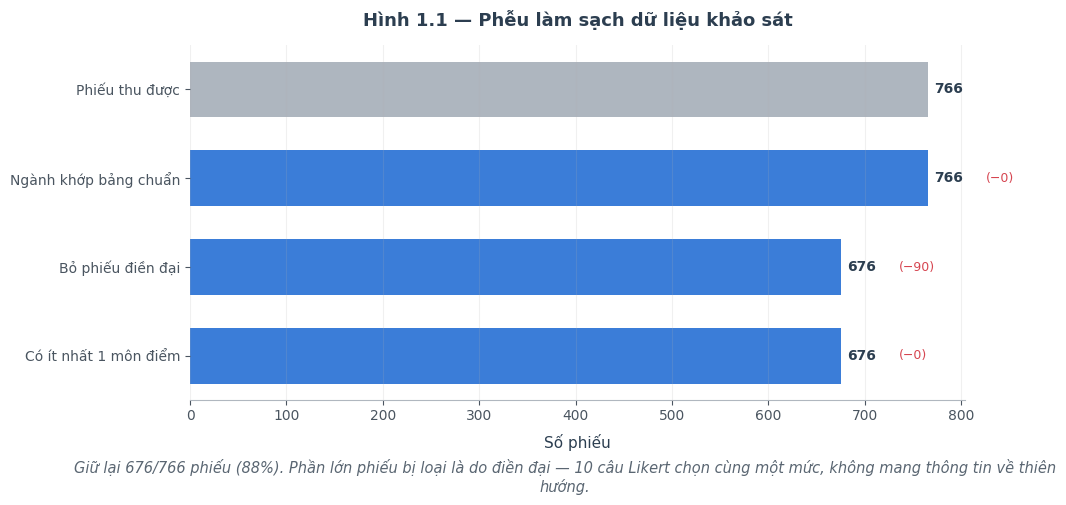

In [3]:
# ═══════════ HÌNH 1.1 — Phễu lọc ═══════════
fig, ax = plt.subplots(figsize=(10, 4.6))
ten = [b[0] for b in buoc]; sl = [b[1] for b in buoc]
mau = [C_XAM] + [C_XANH] * (len(buoc) - 1)
ax.barh(range(len(buoc))[::-1], sl, color=mau, height=.62)
ax.set_yticks(range(len(buoc))[::-1]); ax.set_yticklabels(ten, fontsize=10)
ax.set_xlabel("Số phiếu"); ax.set_title("Hình 1.1 — Phễu làm sạch dữ liệu khảo sát")
ax.grid(axis="y", alpha=0)
for i, n in enumerate(sl):
    ax.text(n + 6, len(buoc) - 1 - i, f"{n:,}", va="center", fontweight="bold",
            fontsize=10)
    if i:
        ax.text(n + 60, len(buoc) - 1 - i, f"(−{sl[i-1]-n})", va="center",
                fontsize=9, color=C_THAT)
luu(fig, OUT, "hinh_1_1_pheu_loc.png",
    f"Giữ lại {sl[-1]}/{sl[0]} phiếu ({sl[-1]/sl[0]:.0%}). Phần lớn phiếu bị loại là do điền đại "
    "— 10 câu Likert chọn cùng một mức, không mang thông tin về thiên hướng.")
plt.show()

## 2. Phân bố ngành và khối

   💾 hinh_1_2_phan_bo.png


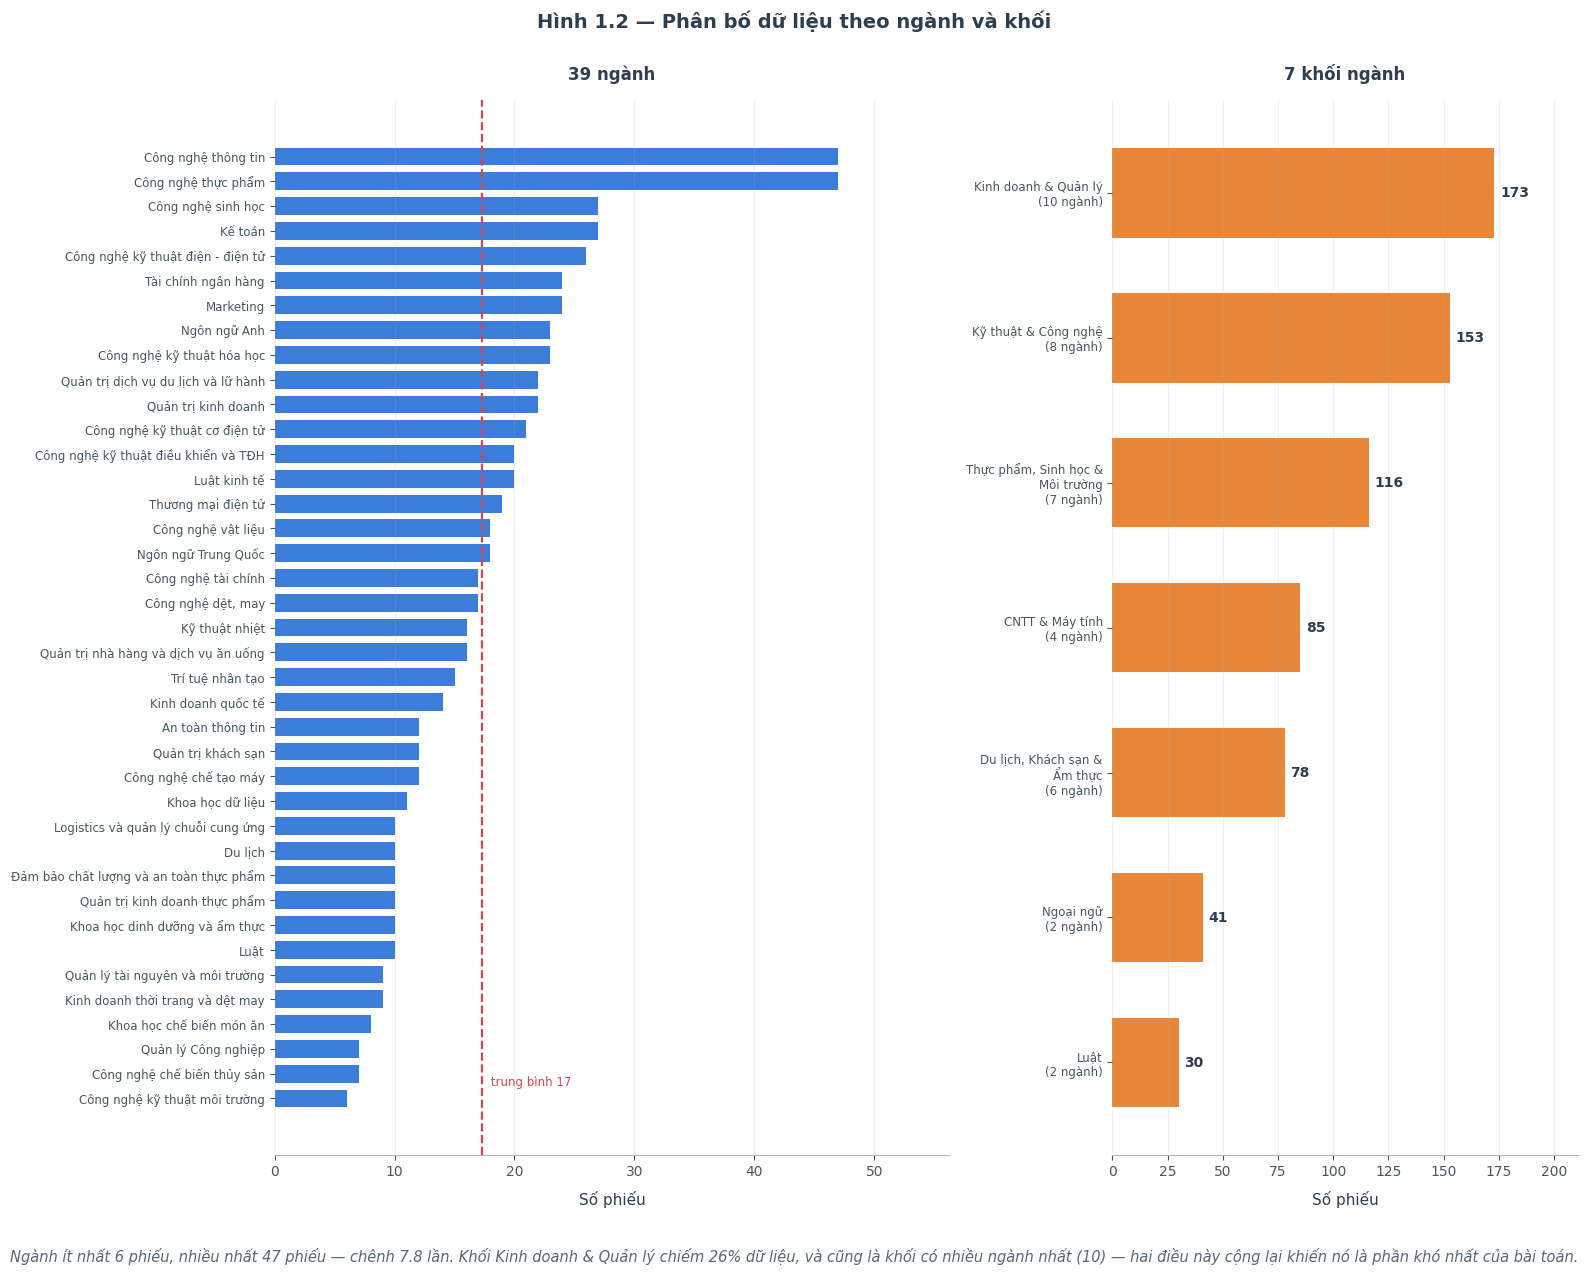

In [4]:
co_nganh = d.ma_nganh.value_counts()
co_khoi = d.ma_khoi.value_counts().sort_index()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, cao_theo_dong(len(co_nganh))),
                             gridspec_kw={"width_ratios": [1.45, 1]})
s = co_nganh.sort_values()
a1.barh(range(len(s)), s.values, color=C_XANH, height=.72)
a1.set_yticks(range(len(s)))
a1.set_yticklabels([MA_TO_TEN[m] for m in s.index], fontsize=8.5)
a1.set_xlabel("Số phiếu"); a1.set_title("39 ngành", fontsize=12)
a1.grid(axis="y", alpha=0)
cho_chu_giai(a1, phan=.14)
a1.axvline(s.mean(), color=C_THAT, ls="--", lw=1.6)
a1.text(s.mean() + .4, 0.5, f" trung bình {s.mean():.0f}", fontsize=8.5, color=C_THAT)

k = co_khoi.sort_values()
a2.barh(range(len(k)), k.values, color=C_CAM, height=.62)
a2.set_yticks(range(len(k)))
a2.set_yticklabels([f"{ngat_dong(TEN_KHOI[i], 22)}\n({len(KHOI[i])} ngành)"
                    for i in k.index], fontsize=8.5)
a2.set_xlabel("Số phiếu"); a2.set_title(f"{len(KHOI)} khối ngành", fontsize=12)
a2.grid(axis="y", alpha=0)
cho_chu_giai(a2, phan=.16)
nhan_ngang(a2, k.values, "{:,.0f}")

fig.suptitle("Hình 1.2 — Phân bố dữ liệu theo ngành và khối",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_1_2_phan_bo.png",
    f"Ngành ít nhất {s.min()} phiếu, nhiều nhất {s.max()} phiếu — chênh {s.max()/s.min():.1f} lần. "
    f"Khối {TEN_KHOI[co_khoi.idxmax()]} chiếm {co_khoi.max()/len(d):.0%} dữ liệu, và cũng là khối "
    f"có nhiều ngành nhất ({max(len(v) for v in KHOI.values())}) — hai điều này cộng lại khiến nó "
    "là phần khó nhất của bài toán.")
plt.show()

## 3. Câu trả lời Likert

   💾 hinh_1_3_likert.png


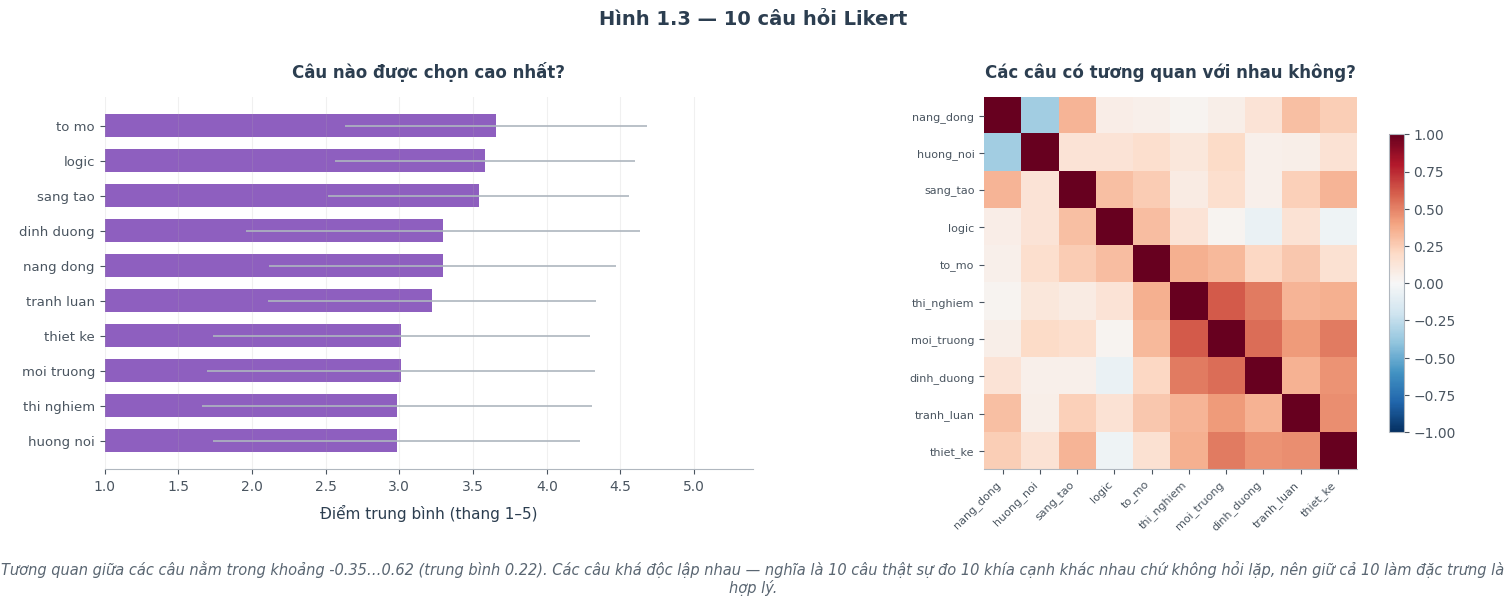

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.4))
Lk = d[L].astype(float)
tb = Lk.mean().sort_values()
a1.barh(range(len(tb)), tb.values, color=C_TIM, height=.66,
        xerr=Lk.std()[tb.index].values, error_kw=dict(ecolor=C_XAM, lw=1.2))
a1.set_yticks(range(len(tb)))
a1.set_yticklabels([c.replace("likert_", "").replace("_", " ") for c in tb.index],
                   fontsize=9.5)
a1.set_xlabel("Điểm trung bình (thang 1–5)"); a1.set_xlim(1, 5.4)
a1.set_title("Câu nào được chọn cao nhất?", fontsize=12); a1.grid(axis="y", alpha=0)

cor = Lk.corr().values
im = a2.imshow(cor, cmap="RdBu_r", vmin=-1, vmax=1)
nl = [c.replace("likert_", "")[:11] for c in L]
a2.set_xticks(range(len(L))); a2.set_xticklabels(nl, rotation=45, ha="right", fontsize=8)
a2.set_yticks(range(len(L))); a2.set_yticklabels(nl, fontsize=8)
a2.set_title("Các câu có tương quan với nhau không?", fontsize=12); a2.grid(alpha=0)
fig.colorbar(im, ax=a2, shrink=.8)

fig.suptitle("Hình 1.3 — 10 câu hỏi Likert", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
ngoai = cor[np.triu_indices(len(L), 1)]
luu(fig, OUT, "hinh_1_3_likert.png",
    f"Tương quan giữa các câu nằm trong khoảng {ngoai.min():.2f}…{ngoai.max():.2f} "
    f"(trung bình {ngoai.mean():.2f}). Các câu khá độc lập nhau — nghĩa là 10 câu thật sự đo 10 "
    "khía cạnh khác nhau chứ không hỏi lặp, nên giữ cả 10 làm đặc trưng là hợp lý.")
plt.show()

## 4. Điểm thi và nhân khẩu học

   💾 hinh_1_4_diem_nhankhau.png


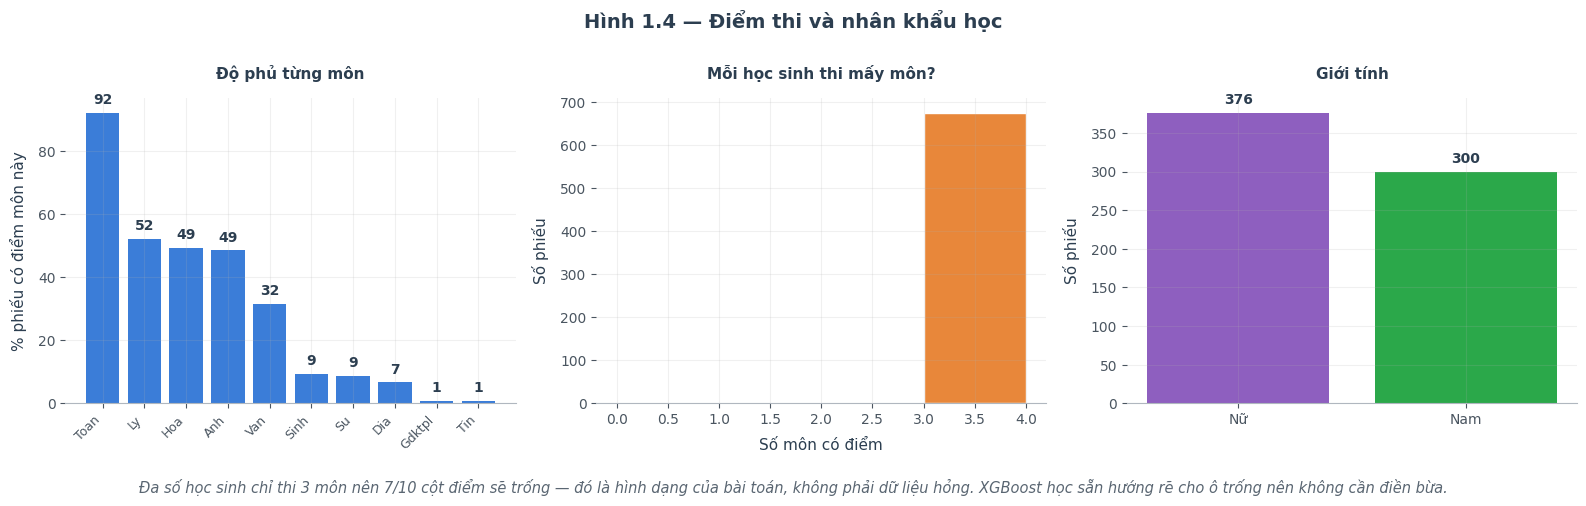

In [6]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.6))
phu = d[C_DIEM].notna().mean().sort_values(ascending=False) * 100
a1.bar(range(len(phu)), phu.values, color=C_XANH)
a1.set_xticks(range(len(phu)))
a1.set_xticklabels([c.replace("diem_", "") for c in phu.index], rotation=45,
                   ha="right", fontsize=9)
a1.set_ylabel("% phiếu có điểm môn này"); a1.set_title("Độ phủ từng môn", fontsize=11)
nhan_doc(a1, "{:.0f}")

so_mon = d[C_DIEM].notna().sum(axis=1)
a2.hist(so_mon, bins=range(0, so_mon.max() + 2), color=C_CAM, edgecolor="white")
a2.set_xlabel("Số môn có điểm"); a2.set_ylabel("Số phiếu")
a2.set_title("Mỗi học sinh thi mấy môn?", fontsize=11)

gt = d.gioi_tinh.value_counts()
a3.bar(range(len(gt)), gt.values, color=[C_TIM, C_GA, C_XAM][:len(gt)])
a3.set_xticks(range(len(gt))); a3.set_xticklabels(gt.index, fontsize=10)
a3.set_ylabel("Số phiếu"); a3.set_title("Giới tính", fontsize=11)
nhan_doc(a3, "{:,.0f}")

fig.suptitle("Hình 1.4 — Điểm thi và nhân khẩu học", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_1_4_diem_nhankhau.png",
    f"Đa số học sinh chỉ thi {int(so_mon.mode()[0])} môn nên {len(C_DIEM)-int(so_mon.mode()[0])}"
    f"/{len(C_DIEM)} cột điểm sẽ trống — đó là hình dạng của bài toán, không phải dữ liệu hỏng. "
    "XGBoost học sẵn hướng rẽ cho ô trống nên không cần điền bừa.")
plt.show()

   💾 hinh_1_5_muc_tieu.png


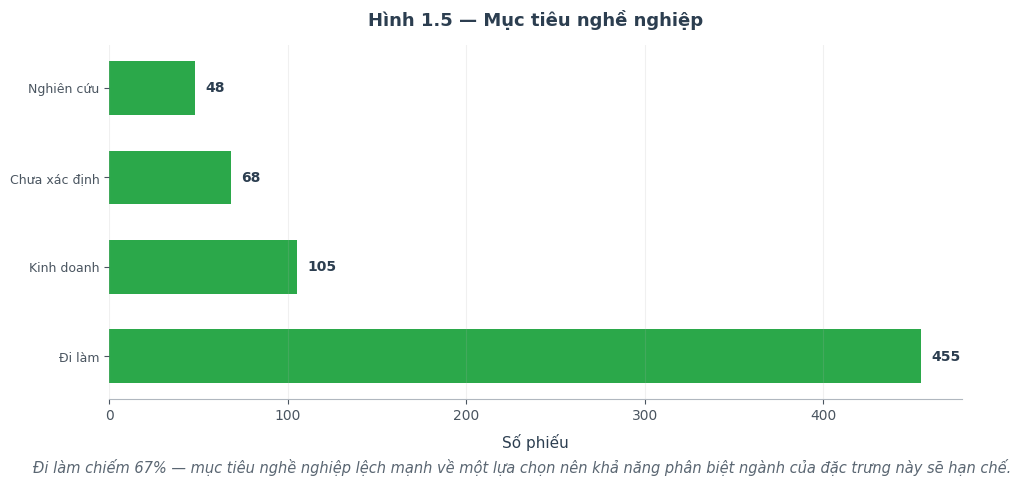

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.6))
mt = d.muc_tieu_nhan.value_counts() if "muc_tieu_nhan" in d else d.muc_tieu_ma.value_counts()
ax.barh(range(len(mt)), mt.values, color=C_GA, height=.6)
ax.set_yticks(range(len(mt)))
ax.set_yticklabels([str(x)[:46] for x in mt.index], fontsize=9)
ax.set_xlabel("Số phiếu"); ax.set_title("Hình 1.5 — Mục tiêu nghề nghiệp")
ax.grid(axis="y", alpha=0)
nhan_ngang(ax, mt.values, "{:,.0f}")
luu(fig, OUT, "hinh_1_5_muc_tieu.png",
    f"{mt.index[0]} chiếm {mt.iloc[0]/mt.sum():.0%} — mục tiêu nghề nghiệp lệch mạnh về một lựa "
    "chọn nên khả năng phân biệt ngành của đặc trưng này sẽ hạn chế.")
plt.show()

## 5. Xuất dữ liệu sạch và bảng ánh xạ chuẩn

In [8]:
d.to_csv(OUT / "khaosat_sach.csv", index=False)

mapping = {
    "ten_cach_nhom": "khối ngành (HUIT)",
    "ten_to_ma": TEN_TO_MA,
    "ma_to_ten": {str(m): t for m, t in MA_TO_TEN.items()},
    "nganh_to_nhom": {str(m): k for m, k in NGANH_TO_KHOI.items()},
    "ten_nhom": {str(k): v for k, v in TEN_KHOI.items()},
    "nhom_chi_tiet": {str(k): [t for t, _ in v] for k, v in KHOI.items()},
    "cot_likert": L,
    "cot_diem": C_DIEM,
    "n_sach": len(d),
    "ghi_chu": ("Nguồn chuẩn duy nhất cho toàn pipeline. Đây cũng là file DUY NHẤT "
                "khác nhau giữa research2 và research3."),
}
(OUT / "mapping.json").write_text(
    json.dumps(mapping, ensure_ascii=False, indent=2), encoding="utf-8")

pd.DataFrame([{"ma_nganh": m, "nganh_hoc": MA_TO_TEN[m], "ma_khoi": NGANH_TO_KHOI[m],
               "ten_khoi": TEN_KHOI[NGANH_TO_KHOI[m]], "so_phieu": int(co_nganh[m])}
              for m in sorted(MA_TO_TEN)]).to_csv(OUT / "bang_nganh.csv", index=False)

tom_tat("GIAI ĐOẠN 1 — LÀM SẠCH PHIẾU KHẢO SÁT", [
    f"Phiếu thu được         {buoc[0][1]}",
    f"Phiếu dùng được        {len(d)}   ({len(d)/buoc[0][1]:.0%})",
    f"   bỏ vì điền đại      {buoc[1][1] - buoc[2][1]}",
    f"   bỏ vì lý do khác    {buoc[0][1] - len(d) - (buoc[1][1] - buoc[2][1])}",
    "",
    f"Ngành                  {d.ma_nganh.nunique()}   (ít nhất {co_nganh.min()} phiếu,"
    f" nhiều nhất {co_nganh.max()})",
    f"Khối ngành             {len(KHOI)}   cỡ {sorted((len(v) for v in KHOI.values()), reverse=True)}",
    f"Đặc trưng gốc          {len(L)} câu Likert · {len(C_DIEM)} môn điểm"
    " · tổ hợp · giới tính · mục tiêu",
])
print(f"\n✅ khaosat_sach.csv · mapping.json · bang_nganh.csv · 5 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 1 — LÀM SẠCH PHIẾU KHẢO SÁT                    ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Phiếu thu được         766                                                 ║
║ Phiếu dùng được        676   (88%)                                         ║
║    bỏ vì điền đại      90                                                  ║
║    bỏ vì lý do khác    0                                                   ║
║                                                                            ║
║ Ngành                  39   (ít nhất 6 phiếu, nhiều nhất 47)               ║
║ Khối ngành             7   cỡ [10, 8, 7, 6, 4, 2, 2]                       ║
║ Đặc trưng gốc          10 câu Likert · 10 môn điểm · tổ hợp · giới tính ·  ║
╚════════════════════════════════════════════════════════════════════════════╝

✅ khaosat_sach.csv · mapping.json · bang_nganh.csv 